<a href="https://colab.research.google.com/github/padmesh-b/few-shot-skin-disease-classification/blob/main/Few_Shot_Skin_Disease_Classification_using_Prototypical_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip novel.zip

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/dataset/novel"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Few-Shot Skin Disease Classification using Prototypical Networks

## Project Overview

This project implements a Few-Shot Learning framework for skin disease classification using Prototypical Networks. Instead of requiring thousands of labeled images, the model learns representative prototypes from only a few support images per class.

The workflow combines:

- DenseNet121 as a pretrained feature extractor
- Prototypical Network classification
- K-Means clustering for representative support image selection
- Euclidean distance based prediction
- Explainable AI using Grad-CAM
- False Negative Analysis for model evaluation

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

# DenseNet121 Feature Extractor

In [6]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(128,128,3)
)
encoder = Model(
    inputs=base_model.input,
    outputs=base_model.output
)
print("ready")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ready


# Image Embedding Generation

In [7]:
IMG_SIZE = 128
def get_embedding(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )
    img = img.astype("float32")
    img = preprocess_input(img)
    img = np.expand_dims(
        img,
        axis=0
    )
    embedding = encoder.predict(
        img,
        verbose=0
    )
    return embedding[0]

# K-Means Support Image Selection

In [8]:
from sklearn.cluster import KMeans
import numpy as np
import os
def select_support_query(class_folder,n_support=5):
    image_paths = [
        os.path.join(class_folder,img)
        for img in os.listdir(class_folder)
    ]
    embeddings = []
    for path in image_paths:
        emb = get_embedding(path)
        embeddings.append(emb)
    embeddings = np.array(embeddings)
    kmeans = KMeans(
        n_clusters=n_support,
        random_state=42,
        n_init=10
    )
    clusters = kmeans.fit_predict(
        embeddings
    )
    support = []
    for cluster_id in range(n_support):
        idx = np.where(
            clusters == cluster_id
        )[0]
        cluster_emb = embeddings[idx]
        center = kmeans.cluster_centers_[
            cluster_id
        ]
        distances = np.linalg.norm(
            cluster_emb-center,
            axis=1
        )
        best = idx[
            np.argmin(distances)
        ]
        support.append(
            image_paths[best]
        )
    query = [
        img
        for img in image_paths
        if img not in support
    ]
    return support,query

# Prototype Generation

In [9]:
def create_prototype(image_paths, n_samples=5):
    if isinstance(image_paths, str):
        image_paths = [
            os.path.join(image_paths, img)
            for img in os.listdir(image_paths)
        ]
    if n_samples is not None:
        image_paths = image_paths[:n_samples]
    embeddings = []
    for path in image_paths:
        emb = get_embedding(path)
        embeddings.append(emb)
    return np.mean(embeddings, axis=0)

# Selected Support Images

In [10]:
import os

for cls in ["df", "vasc", "akiec"]:
    folder = f"/content/drive/MyDrive/dataset/novel1/{cls}/support"
    print(f"\n{cls}:")
    print(os.listdir(folder))


df:
['ISIC_0024973.jpg', 'ISIC_0032138.jpg', 'ISIC_0027613.jpg', 'ISIC_0027216.jpg', 'ISIC_0033626.jpg']

vasc:
['ISIC_0025628.jpg', 'ISIC_0033092.jpg', 'ISIC_0026467.jpg', 'ISIC_0031217.jpg', 'ISIC_0033349.jpg']

akiec:
['ISIC_0027529.jpg', 'ISIC_0031692.jpg', 'ISIC_0025808.jpg', 'ISIC_0026319.jpg', 'ISIC_0031421.jpg']


# Creating Class Prototypes

In [11]:
df_proto = create_prototype(
    "/content/drive/MyDrive/dataset/novel1/df/support"
)
vasc_proto = create_prototype(
    "/content/drive/MyDrive/dataset/novel1/vasc/support"
)
akiec_proto = create_prototype(
    "/content/drive/MyDrive/dataset/novel1/akiec/support"
)
print("prototypes ready!")

prototypes ready!


# Prototype-Based Classification

In [12]:
def predict_class(image_path):
    query_emb = get_embedding(image_path)
    distances = {
        "df": np.linalg.norm(query_emb - df_proto),
        "vasc": np.linalg.norm(query_emb - vasc_proto),
        "akiec": np.linalg.norm(query_emb - akiec_proto)
    }
    prediction = min(
        distances,
        key=distances.get
    )
    values = np.array(list(distances.values()))
    scores = np.exp(-values)
    probs = scores / scores.sum()
    confidence = (
        probs[
            list(distances.keys()).index(prediction)
        ] * 100
    )
    return prediction, confidence, distances

# Model Testing

df


Prediction: df
Confidence: 59.07 %
Distances: {'df': np.float32(33.70503), 'vasc': np.float32(37.34969), 'akiec': np.float32(34.110477)}


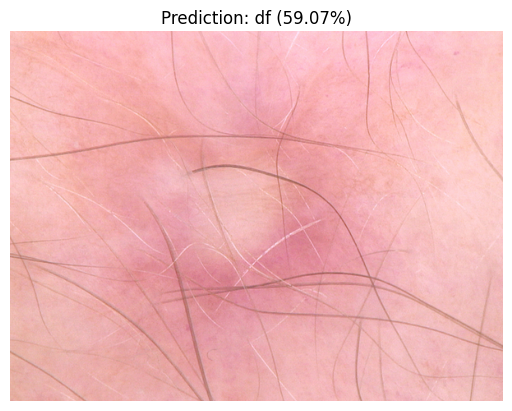

In [13]:
sample = os.listdir(
    "/content/drive/MyDrive/dataset/novel1/df/query"
)[8]
path = os.path.join(
    "/content/drive/MyDrive/dataset/novel1/df/query",
    sample
)
pred, conf, dist = predict_class(path)
print("Prediction:", pred)
print("Confidence:", round(conf, 2), "%")
print("Distances:", dist)
img = cv2.imread(path)
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)
plt.imshow(img)
plt.title(
    f"Prediction: {pred} ({conf:.2f}%)"
)
plt.axis("off")
plt.show()

vasc

Prediction: vasc
Confidence: 99.76 %
Distances: {'df': np.float32(27.426146), 'vasc': np.float32(20.723846), 'akiec': np.float32(27.48552)}


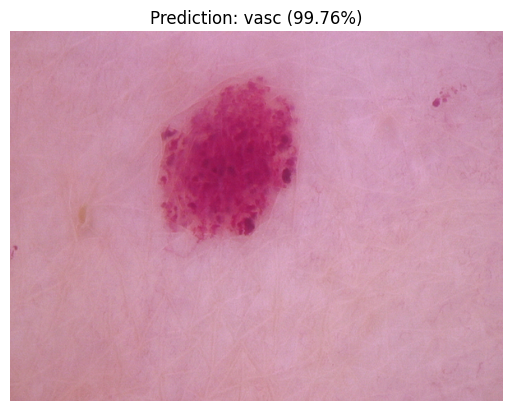

In [14]:
sample = os.listdir(
    "/content/drive/MyDrive/dataset/novel1/vasc/query"
)[9]
path = os.path.join(
    "/content/drive/MyDrive/dataset/novel1/vasc/query",
    sample
)
pred, conf, dist = predict_class(path)
print("Prediction:", pred)
print("Confidence:", round(conf, 2), "%")
print("Distances:", dist)
img = cv2.imread(path)
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)
plt.imshow(img)
plt.title(
    f"Prediction: {pred} ({conf:.2f}%)"
)
plt.axis("off")
plt.show()

akiec

Prediction: akiec
Confidence: 99.49 %
Distances: {'df': np.float32(25.478569), 'vasc': np.float32(31.531261), 'akiec': np.float32(20.208408)}


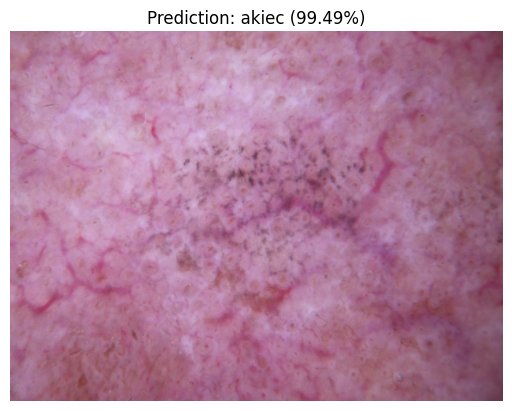

In [15]:
sample = os.listdir(
    "/content/drive/MyDrive/dataset/novel1/akiec/query"
)[8]
path = os.path.join(
    "/content/drive/MyDrive/dataset/novel1/akiec/query",
    sample
)
pred, conf, dist = predict_class(path)
print("Prediction:", pred)
print("Confidence:", round(conf, 2), "%")
print("Distances:", dist)
img = cv2.imread(path)
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)
plt.imshow(img)
plt.title(
    f"Prediction: {pred} ({conf:.2f}%)"
)
plt.axis("off")
plt.show()

In [16]:
import os

for cls in ["df", "vasc", "akiec"]:
    support = len(os.listdir(f"/content/drive/MyDrive/dataset/novel1/{cls}/support"))
    query = len(os.listdir(f"/content/drive/MyDrive/dataset/novel1/{cls}/query"))

    print(f"{cls}: Support={support}, Query={query}")

df: Support=5, Query=110
vasc: Support=5, Query=137
akiec: Support=5, Query=322


# Performance Evaluation

In [17]:
true_labels = []
pred_labels = []
for cls in ["df","vasc","akiec"]:
    folder = f"/content/drive/MyDrive/dataset/novel1/{cls}/query"
    for img in os.listdir(folder):
        path = os.path.join(folder,img)
        pred,conf,dist = predict_class(path)
        true_labels.append(cls)
        pred_labels.append(pred)

# Accuracy Analysis

In [18]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    true_labels,
    pred_labels
)

print(acc * 100)

76.44991212653778


# Confusion Matrix

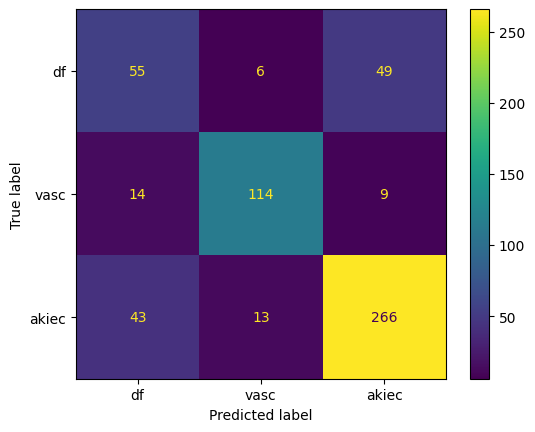

In [19]:
cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=["df", "vasc", "akiec"]
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["df", "vasc", "akiec"]
)
disp.plot()
plt.show()

# N-Shot Learning Comparison

In [20]:
from sklearn.metrics import accuracy_score
shots = [1,3,5]
results = []
for shot in shots:
    print(f"\nRunning {shot}-shot experiment...")
    df_proto = create_prototype(
        "/content/drive/MyDrive/dataset/novel1/df/support",
        n_samples=shot
    )
    vasc_proto = create_prototype(
        "/content/drive/MyDrive/dataset/novel1/vasc/support",
        n_samples=shot
    )
    akiec_proto = create_prototype(
        "/content/drive/MyDrive/dataset/novel1/akiec/support",
        n_samples=shot
    )
    true_labels = []
    pred_labels = []
    for cls in ["df", "vasc", "akiec"]:
        folder = f"/content/drive/MyDrive/dataset/novel1/{cls}/query"
        for img in os.listdir(folder):
            path = os.path.join(folder, img)
            pred, conf, dist = predict_class(path)
            true_labels.append(cls)
            pred_labels.append(pred)
    acc = accuracy_score(
        true_labels,
        pred_labels
    )
    results.append(acc * 100)
    print(
        f"{shot}-shot Accuracy = {acc*100:.2f}%"
    )


Running 1-shot experiment...
1-shot Accuracy = 71.18%

Running 3-shot experiment...
3-shot Accuracy = 66.96%

Running 5-shot experiment...
5-shot Accuracy = 76.45%


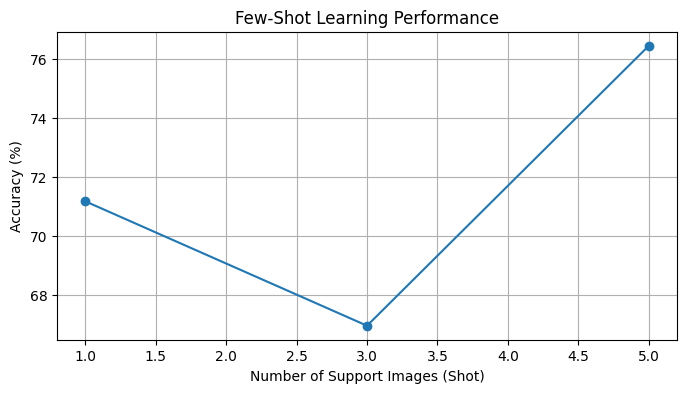

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(
    shots,
    results,
    marker="o"
)
plt.xlabel("Number of Support Images (Shot)")
plt.ylabel("Accuracy (%)")
plt.title(
    "Few-Shot Learning Performance"
)
plt.grid(True)
plt.show()

# Unsupervised Learning using K-Means

In [22]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import pandas as pd

# Embedding Space Visualization (t-SNE)

In [23]:
embeddings = []
labels = []
for cls in ["df","vasc","akiec"]:
    folder = f"/content/drive/MyDrive/dataset/novel1/{cls}/query"
    for img in os.listdir(folder):
        path = os.path.join(folder,img)
        emb = get_embedding(path)
        embeddings.append(emb)
        labels.append(cls)
embeddings = np.array(embeddings)
print("Embeddings Shape:",embeddings.shape)

Embeddings Shape: (569, 1024)


In [24]:
np.save(
    "embeddings.npy",
    embeddings
)

In [25]:
embeddings = np.load(
    "embeddings.npy"
)

print(embeddings.shape)

(569, 1024)


In [26]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(
    embeddings)
print("Clustering Completed")

Clustering Completed


In [27]:
tsne = TSNE(
    n_components=2,
    random_state=42
)
reduced = tsne.fit_transform(
    embeddings
)

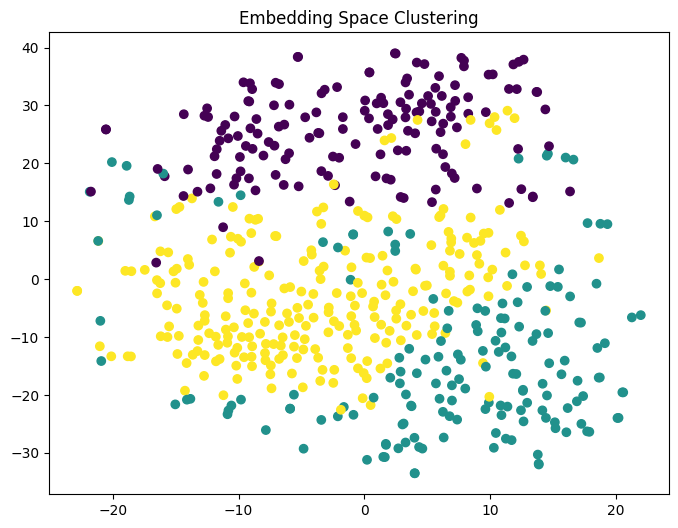

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters
)
plt.title("Embedding Space Clustering")
plt.show()

# Explainable AI using Grad-CAM

In [29]:
df_clusters = pd.DataFrame({
    "Actual":labels,
    "Cluster":clusters
})
print(
    pd.crosstab(
        df_clusters["Cluster"],
        df_clusters["Actual"]
    )
)

Actual   akiec  df  vasc
Cluster                 
0           20  20   114
1          115  40     8
2          187  50    15


In [30]:
for layer in base_model.layers:
    print(layer.name)

input_layer
zero_padding2d
conv1_conv
conv1_bn
conv1_relu
zero_padding2d_1
pool1
conv2_block1_0_bn
conv2_block1_0_relu
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_concat
conv2_block2_0_bn
conv2_block2_0_relu
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_concat
conv2_block3_0_bn
conv2_block3_0_relu
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_concat
conv2_block4_0_bn
conv2_block4_0_relu
conv2_block4_1_conv
conv2_block4_1_bn
conv2_block4_1_relu
conv2_block4_2_conv
conv2_block4_concat
conv2_block5_0_bn
conv2_block5_0_relu
conv2_block5_1_conv
conv2_block5_1_bn
conv2_block5_1_relu
conv2_block5_2_conv
conv2_block5_concat
conv2_block6_0_bn
conv2_block6_0_relu
conv2_block6_1_conv
conv2_block6_1_bn
conv2_block6_1_relu
conv2_block6_2_conv
conv2_block6_concat
pool2_bn
pool2_relu
pool2_conv
pool2_pool
conv3_block1_0_bn
conv3_block1_0_relu
conv3_block1_1_conv
con

In [31]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer(
            "conv5_block16_concat"
        ).output,
        base_model.output
    ]
)

# Grad-CAM Heatmap Generation

In [32]:
def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(
            img_array
        )
        class_channel = tf.reduce_max(
            preds,
            axis=1
        )
    grads = tape.gradient(
        class_channel,
        conv_output
    )
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )
    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(
        pooled_grads * conv_output,
        axis=-1
    )
    heatmap = tf.maximum(
        heatmap,
        0
    )
    heatmap /= (
        tf.reduce_max(
            heatmap
        ) + 1e-10
    )

    return heatmap.numpy()

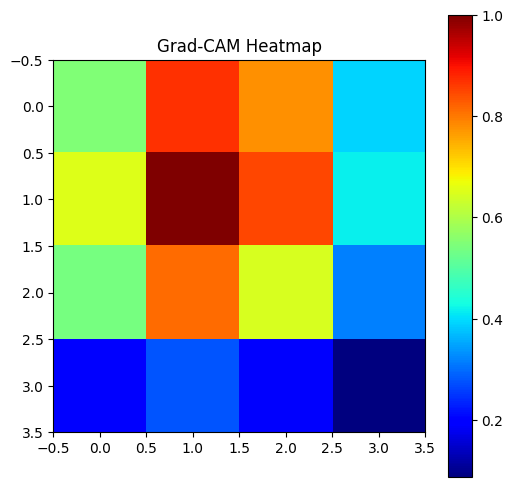

In [33]:
img_path = os.path.join(
    "/content/drive/MyDrive/dataset/novel1/vasc/query",
    os.listdir(
        "/content/drive/MyDrive/dataset/novel1/vasc/query"
    )[9]
)
img = cv2.imread(img_path)
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)
img_resized = cv2.resize(
    img,
    (128,128)
)
img_array = np.expand_dims(
    preprocess_input(
        img_resized.astype(
            "float32"
        )
    ),
    axis=0
)
heatmap = make_gradcam_heatmap(
    img_array
)
plt.figure(figsize=(6,6))
plt.imshow(
    heatmap,
    cmap="jet"
)
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

# False Negative Analysis

In [34]:
false_negatives = []
for actual_class in ["df", "vasc", "akiec"]:
    folder = f"/content/drive/MyDrive/dataset/novel1/{actual_class}/query"
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        pred, conf, dist = predict_class(path)
        if pred != actual_class:
            false_negatives.append({
                "Actual": actual_class,
                "Predicted": pred,
                "Confidence": round(conf,2),
                "Image": path
            })
print("Total False Negatives:", len(false_negatives))

Total False Negatives: 134


In [35]:
import pandas as pd

fn_df = pd.DataFrame(false_negatives)

fn_df.head(10)

,Actual,Predicted,Confidence,Image
0,df,akiec,70.260002,/content/drive/MyDrive/dataset/novel1/df/query...
1,df,akiec,88.120003,/content/drive/MyDrive/dataset/novel1/df/query...
2,df,akiec,95.790001,/content/drive/MyDrive/dataset/novel1/df/query...
3,df,akiec,98.220001,/content/drive/MyDrive/dataset/novel1/df/query...
4,df,akiec,99.669998,/content/drive/MyDrive/dataset/novel1/df/query...
5,df,akiec,99.790001,/content/drive/MyDrive/dataset/novel1/df/query...
6,df,akiec,94.029999,/content/drive/MyDrive/dataset/novel1/df/query...
7,df,akiec,88.360001,/content/drive/MyDrive/dataset/novel1/df/query...
8,df,akiec,92.139999,/content/drive/MyDrive/dataset/novel1/df/query...
9,df,akiec,96.330002,/content/drive/MyDrive/dataset/novel1/df/query...


In [36]:
print("False Negative Count\n")

print(
    fn_df["Actual"].value_counts()
)

False Negative Count

Actual
akiec    56
df       55
vasc     23
Name: count, dtype: int64


In [37]:
classes = ["df","vasc","akiec"]

for cls in classes:

    total = len(
        os.listdir(
            f"/content/drive/MyDrive/dataset/novel1/{cls}/query"
        )
    )

    fn = len(
        fn_df[
            fn_df["Actual"] == cls
        ]
    )

    fnr = fn/total

    print(
        f"{cls}: {fnr*100:.2f}%"
    )

df: 50.00%
vasc: 16.79%
akiec: 17.39%


Actual: vasc
Predicted: df
Confidence: 54.65


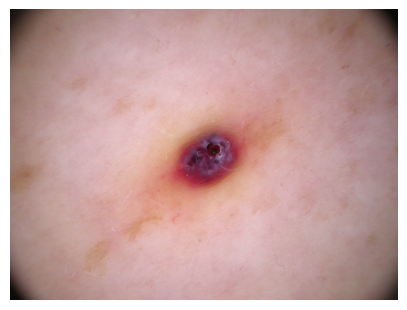

In [38]:
sample = fn_df.sample(3).iloc[0]

print("Actual:", sample["Actual"])
print("Predicted:", sample["Predicted"])
print("Confidence:", sample["Confidence"])

img = cv2.imread(sample["Image"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

# Conclusion

This project demonstrates an efficient Few-Shot Learning framework for skin disease classification.

Key Contributions:

- Transfer Learning using DenseNet121
- Prototype-based Few-Shot Classification
- K-Means Support Image Selection
- Explainable AI using Grad-CAM
- False Negative Analysis
- Performance Evaluation using Accuracy and Confusion Matrix

The framework is suitable for medical image classification where labeled data is limited.